<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/train_simclr_har_0.5s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SimCLR Training

In [2]:
# For VSCode
%load_ext autoreload
%autoreload 2

import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt

sys.path.append('../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

with open('../data_1s_100hz/TrainTest/X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('../data_1s_100hz/TrainTest/y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('../data_1s_100hz/TrainTest/X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('../data_1s_100hz/TrainTest/y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('../data_1s_100hz/TrainTest/X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('../data_1s_100hz/TrainTest/y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

np_train_data.shape, np_train_labels.shape, np_val_data.shape, np_val_labels.shape, np_test_labels.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


((2590, 100, 3), (2590, 7), (648, 100, 3), (648, 7), (810, 7))

In [ ]:
# For Google Colab
# 1. Clone your repository to go to access your notebook and .py files
!git clone https://github.com/Ziyi-star/Bachelorarbeit.git
# 2. Change working directory to where your notebook and .py files are
import os
os.chdir('/content/Bachelorarbeit/notebooks/training')
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import simclr_utitlities
import transformations
import simclr_models
import sys
from utils.preprocessing import *

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load data
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz/TrainTest/X_train_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz/TrainTest/y_train_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz/TrainTest/X_val_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz/TrainTest/y_val_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz/TrainTest/X_test_data.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_100hz/TrainTest/y_test_onehot.pkl


working_directory = "../models/"  # Relative path to models folder

# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

print(np_train_data.shape, np_train_labels.shape)
print(np_val_data.shape, np_val_labels.shape)

Cloning into 'Bachelorarbeit'...
remote: Enumerating objects: 449, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 449 (delta 24), reused 37 (delta 16), pack-reused 399 (from 2)
Receiving objects: 100% (449/449), 144.36 MiB | 27.31 MiB/s, done.
Resolving deltas: 100% (249/249), done.
Updating files: 100% (69/69), done.
--2025-09-18 11:02:57--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_all/TrainTest/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6304965 (6.0M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]   6.01M  --.-KB/s    in 0.06s   

2025-09-18 11:02:58 (92.7 MB/s)

## 1.2 Fine-tuning and Evaluation

### 1.2.1 Linear Model

#### Train

In [3]:
# Time
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
#Formats the date and time as a string like 20250827-153045 (for filenames, logs, etc.).
tf.keras.backend.set_floatx('float32')
#Sets TensorFlow to use 32-bit floating point numbers for all computations (standard for deep learning).


In [4]:
# This block performs linear evaluation on top of the pretrained SimCLR base model.
total_epochs = 50
batch_size = 200
tag = "linear_eval"
output_shape = np_train_labels.shape[1]  # Number of classes for classification

# 1. Loads the SimCLR model and attaches a linear classification head on top.
simclr_model = tf.keras.models.load_model('../models/simclr_pretrained_model_best_1s_100hz.hdf5')
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

# 2. Sets up a ModelCheckpoint callback to save the best model (lowest validation loss).
# This ensures we keep the model version that performs best on validation data
linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(
    linear_eval_best_model_file_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

# 3. Trains the linear evaluation model using the training and validation data.
training_history = linear_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 100, 3))
  warnings.warn(msg)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - auc: 0.6645 - categorical_accuracy: 0.3172 - loss: 2.0281 - precision: 0.4601 - recall: 0.0962 - val_auc: 0.8380 - val_categorical_accuracy: 0.5185 - val_loss: 1.4390 - val_precision: 0.9250 - val_recall: 0.1713
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - auc: 0.8492 - categorical_accuracy: 0.5180 - loss: 1.3888 - precision: 0.8928 - recall: 0.2094 - val_auc: 0.8478 - val_categorical_accuracy: 0.5417 - val_loss: 1.3773 - val_precision: 0.9205 - val_recall: 0.2145
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - auc: 0.8596 - categorical_accuracy: 0.5437 - loss: 1.3281 - precision: 0.8945 - recall: 0.2418 - val_auc: 0.8541 - val_categorical_accuracy: 0.5679 - val_loss: 1.3412 - val_precision: 0.9193 - val_recall: 0.2284
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - auc: 0.8659 - categorical_accuracy: 0.5612 - loss: 1.2955 - precision: 0.8962 - recall: 0.2522 - val_auc: 0.8586 - val_categorical_accuracy: 0.5694 - val_loss: 1.

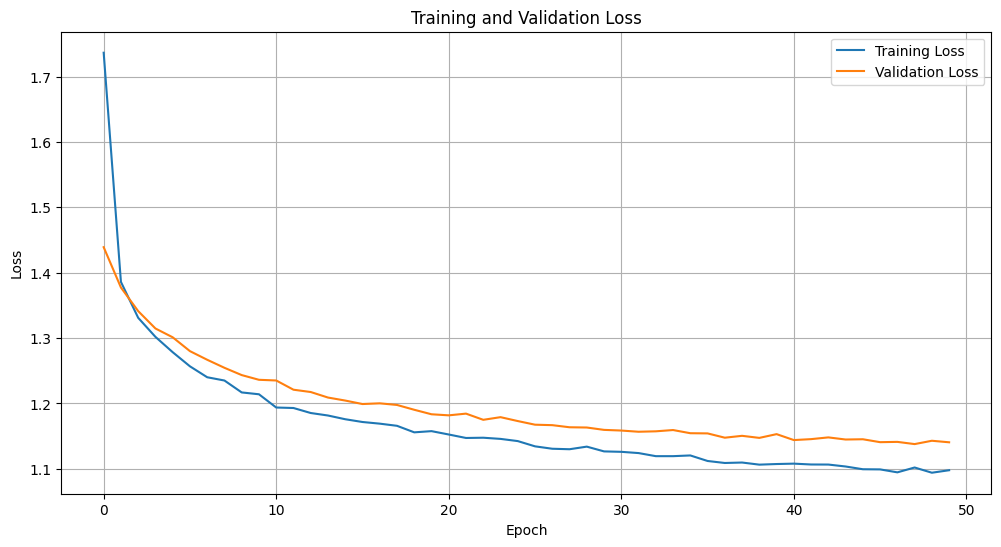

In [5]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

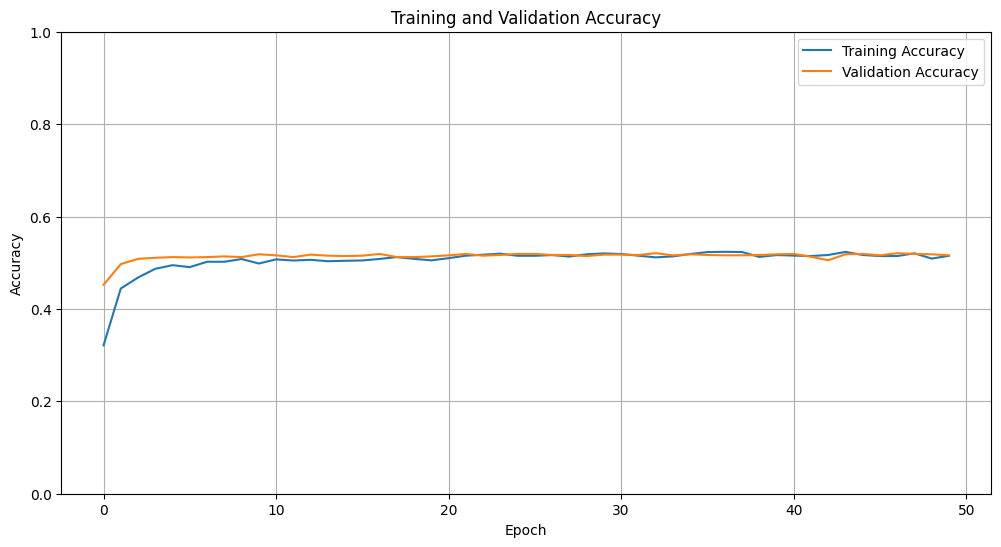

In [13]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [6]:
# Load models and evaluate on test set on vscode
# simclr_model_path = "../models/20250918-072951_simclr.hdf5"
linear_eval_model_path = "../models/20250930-132649_simclr_linear_eval.keras"

# Load both models
# simclr_model = tf.keras.models.load_model(simclr_model_path)
linear_eval_best_model = tf.keras.models.load_model(linear_eval_model_path)

#### Normalize test data

In [7]:
# You can also use it for test data (but should fit the scaler only on training data)
X_test_normalized = normalize_3d_data(np_test_data)

In [8]:
linear_eval_best_model = tf.keras.models.load_model(linear_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(linear_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(linear_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:
24/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 100, 3))
  warnings.warn(msg)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
{'Confusion Matrix': array([[105,   1,  11,   5,   0,   5,  12],
       [  6,  66,   4,   7,   2,   9,   3],
       [ 22,   1,  21,   4,   7,  25,  15],
       [  8,   1,   1,  72,   1,  28,   7],
       [  0,   4,   0,   3, 109,   2,   0],
       [ 12,   0,   3,   5,   1,  76,  18],
       [ 42,   2,   4,   9,   0,  40,  31]]), 'F1 Macro': 0.5794907483599836, 'F1 Micro': 0.5925925925925926, 'F1 Weighted': 0.5804620097084724, 'Precision': 0.6087225445531094, 'Recall': 0.5848308652097632, 'Kappa': np.float64(0.521573919782641)}
Model in last epoch


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 100, 3))
  warnings.warn(msg)


15/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 100, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 100, 3))
  warnings.warn(msg)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
{'Confusion Matrix': array([[105,   0,  10,   4,   1,   5,  14],
       [  6,  64,   4,   6,   2,  11,   4],
       [ 22,   0,  21,   4,   8,  25,  15],
       [  8,   0,   1,  72,   1,  29,   7],
       [  0,   4,   0,   3, 109,   2,   0],
       [ 12,   0,   3,   5,   1,  76,  18],
       [ 42,   2,   4,   9,   0,  40,  31]]), 'F1 Macro': 0.5781198430566629, 'F1 Micro': 0.5901234567901235, 'F1 Weighted': 0.57899625575066, 'Precision': 0.6123087172607756, 'Recall': 0.581885357109616, 'Kappa': np.float64(0.5185459701588734)}


## Extra: t-SNE Plots

In [10]:
import sklearn.manifold
import seaborn as sns

# First load the model from the file path
target_model_path = "../models/simclr_pretrained_model_best_1s_100hz.hdf5"
loaded_model = tf.keras.models.load_model(target_model_path)
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(loaded_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(X_test_normalized, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "base_model_simclr_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_33 (Conv1D)              │ (None, 77, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 77, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 62, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 55, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 55, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 84,416 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(600, 100, 3))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step 

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 100, 3))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 810 samples in 0.002s...
[t-SNE] Computed neighbors for 810 samples in 0.442s...
[t-SNE] Computed conditional probabilities for sample 810 / 810
[t-SNE] Mean sigma: 1.652909
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.488205
[t-SNE] KL divergence after 1000 iterations: 0.652844


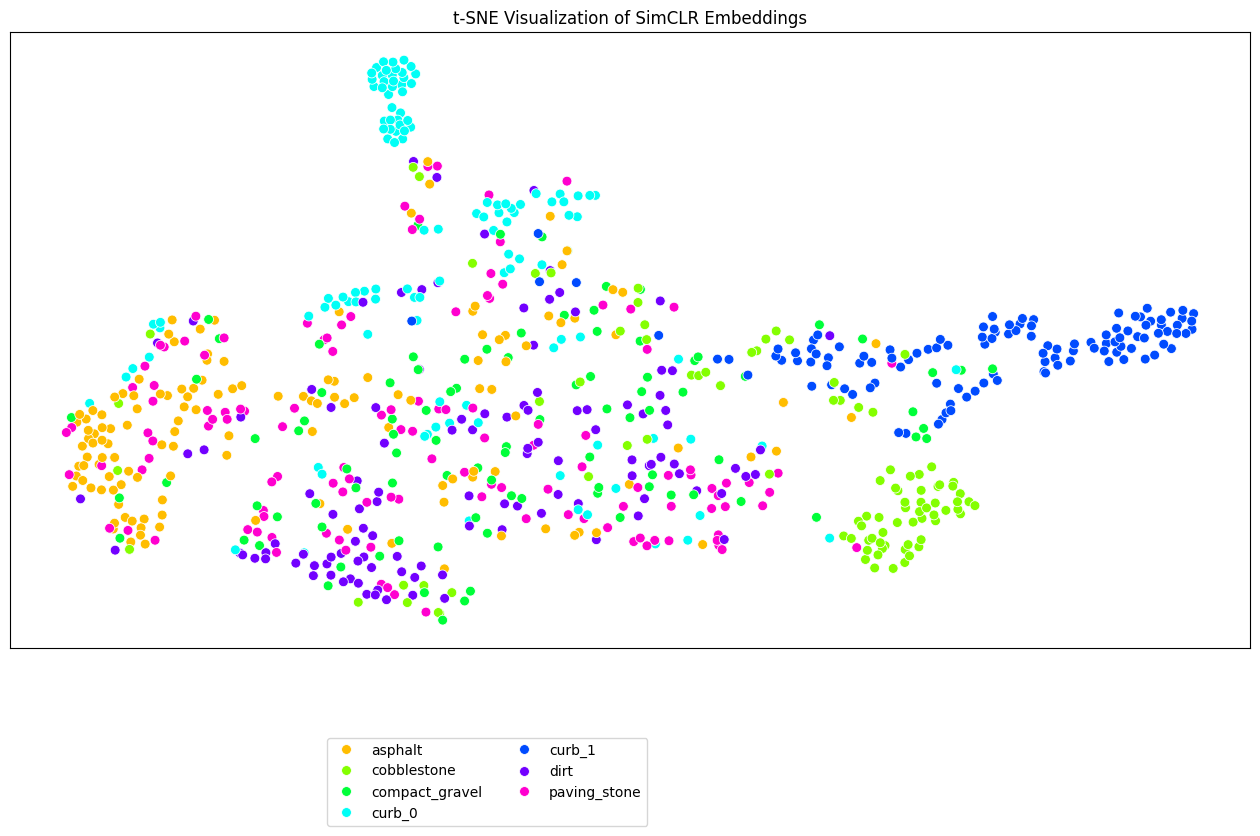

In [11]:
# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_labels, axis=1)
unique_labels = np.unique(labels_argmax)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=sns.color_palette("hsv", len(unique_labels)),
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# If you have class names, use them for the legend
# Define your activity names if needed
label_list_full_name = ["asphalt", "cobblestone", "compact_gravel", "curb_0", "curb_1", "dirt", "paving_stone"]  # Replace with your actual class names

# Update legend with class names if available
plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
legend = graph.legend_
if 'label_list_full_name' in globals():  # Check if variable exists
    for j, label in enumerate(unique_labels):
        if label < len(label_list_full_name):
            legend.get_texts()[j].set_text(label_list_full_name[label])

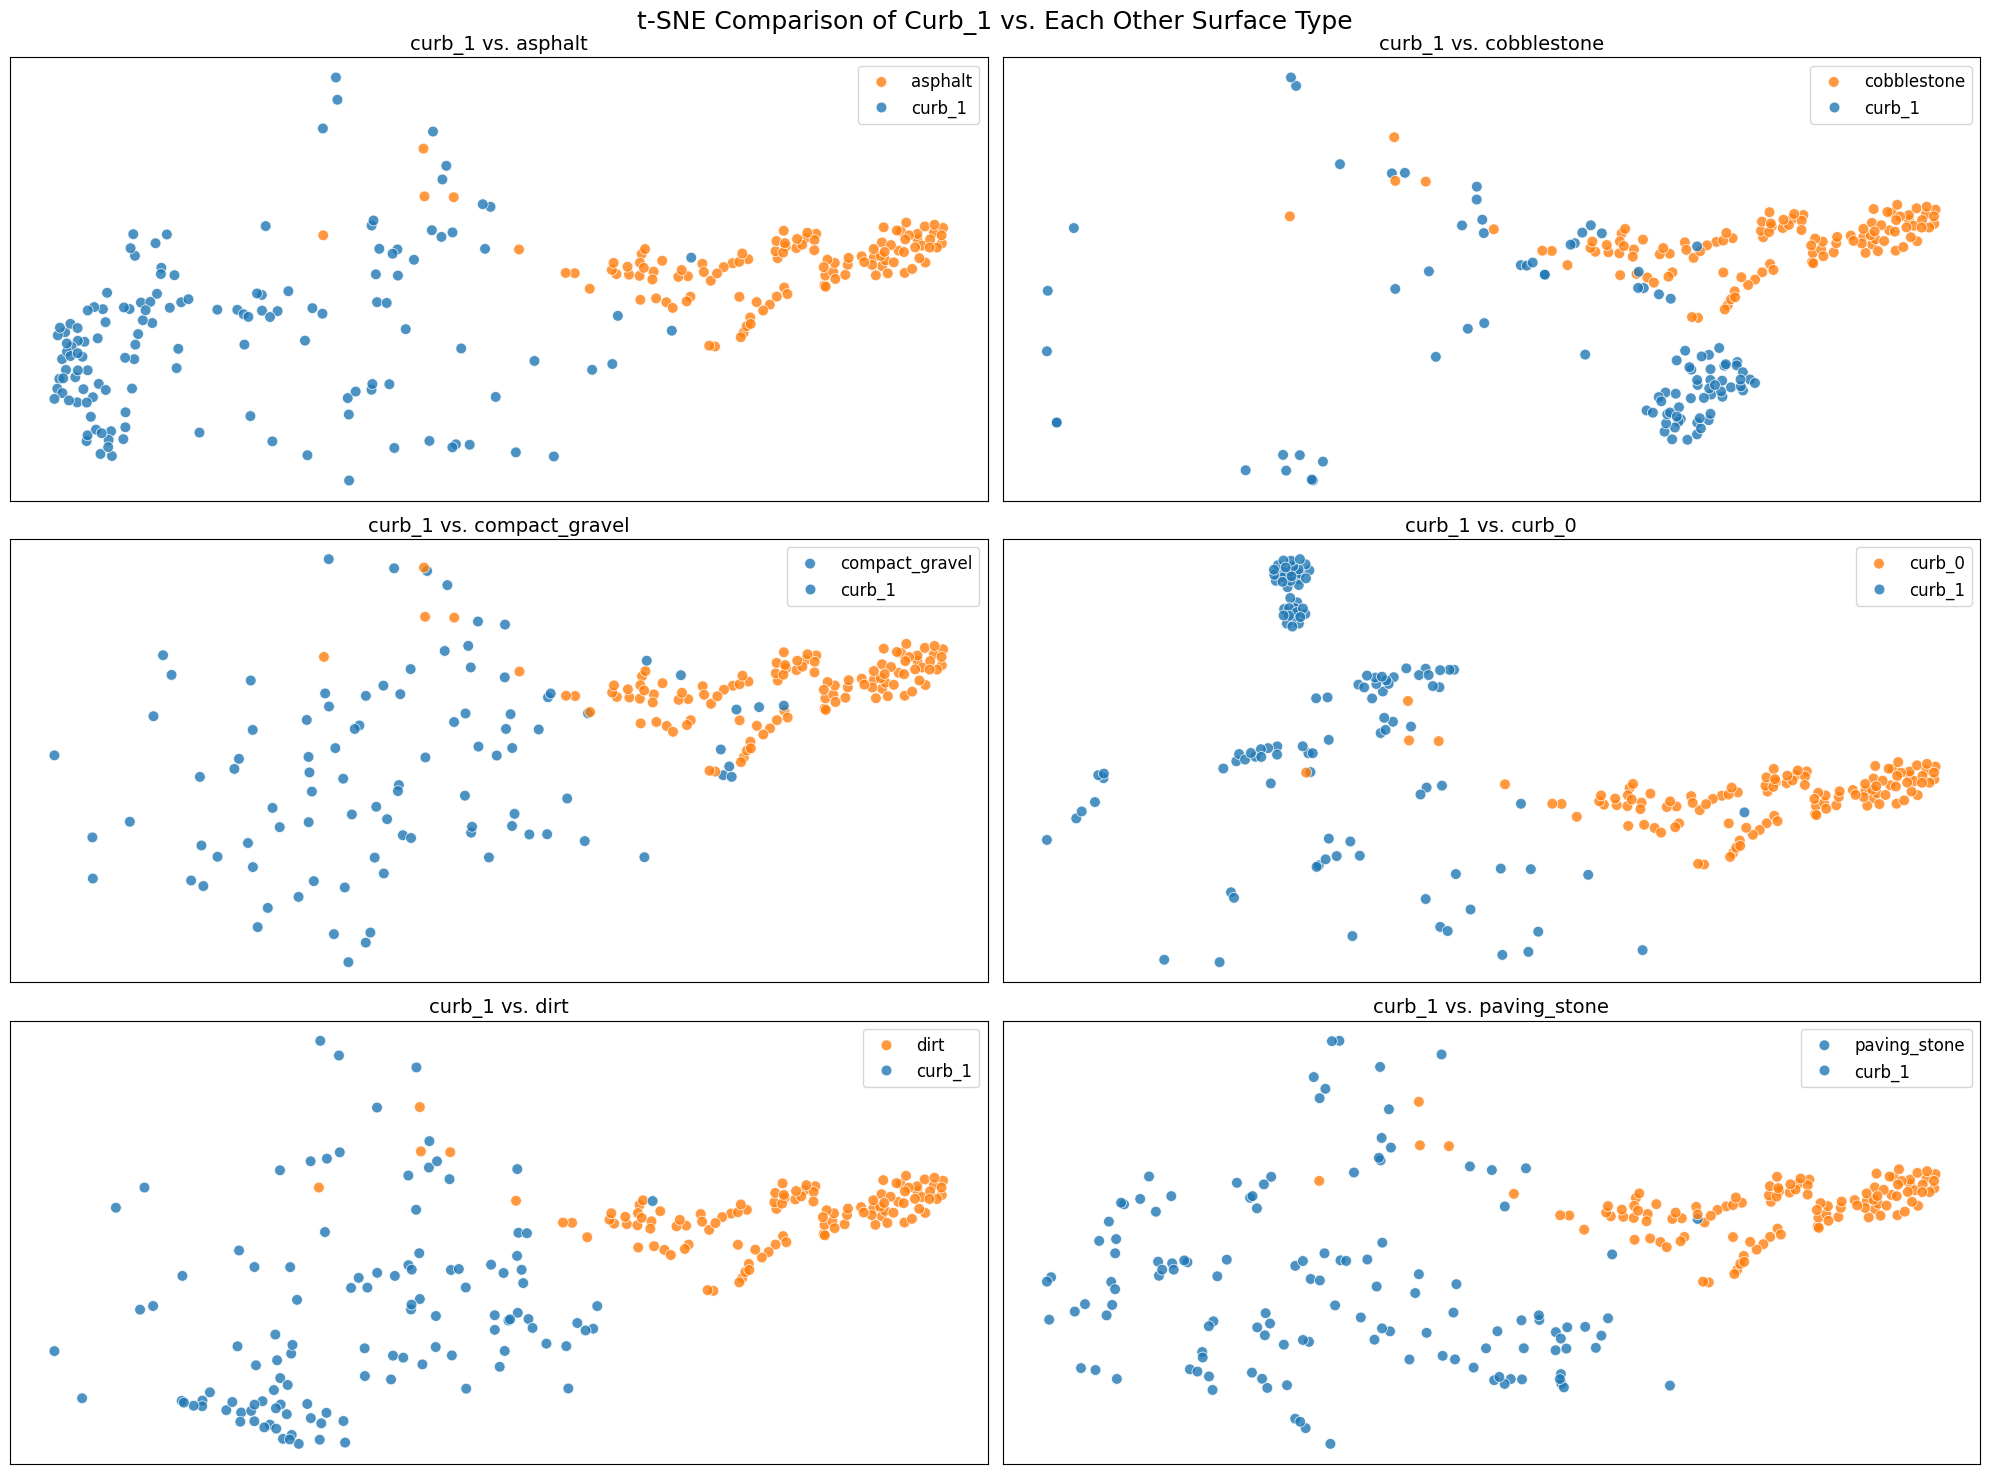

In [12]:
# Create a figure with 6 subplots (3x2 grid) to compare curb_1 with each other class
plt.figure(figsize=(20, 15))

# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_labels, axis=1)
unique_labels = np.unique(labels_argmax)
curb_1_index = 4  # Based on your label_list_full_name where "curb_1" is at index 4

# Define your surface type names
label_list_full_name = ["asphalt", "cobblestone", "compact_gravel", "curb_0", "curb_1", "dirt", "paving_stone"]

# Loop through each class (except curb_1) and create a subplot
subplot_index = 1
for class_index in unique_labels:
    # Skip curb_1 as we're comparing others against it
    if class_index == curb_1_index:
        continue
        
    # Create binary mask for current pair (curb_1 and current class)
    mask = np.logical_or(labels_argmax == curb_1_index, labels_argmax == class_index)
    
    # Create binary labels: 0 for current class, 1 for curb_1
    binary_labels = np.zeros(np.sum(mask))
    binary_labels[labels_argmax[mask] == curb_1_index] = 1
    
    # Get the filtered t-SNE projections
    filtered_projections = tsne_projections[mask]
    
    # Create subplot
    plt.subplot(3, 2, subplot_index)
    
    # Plot the scatter points
    sns.scatterplot(
        x=filtered_projections[:, 0], 
        y=filtered_projections[:, 1],
        hue=binary_labels,
        palette=["#1f77b4", "#ff7f0e"],  # Blue for other class, Orange for curb_1
        s=60,
        alpha=0.8
    )
    
    # Remove axes ticks for cleaner visualization
    plt.xticks([], [])
    plt.yticks([], [])
    
    # Set subplot title
    plt.title(f"curb_1 vs. {label_list_full_name[class_index]}", fontsize=14)
    
    # Custom legend
    plt.legend([label_list_full_name[class_index], "curb_1"], fontsize=12)
    
    # Increment subplot index
    subplot_index += 1

# Add overall title
plt.suptitle("t-SNE Comparison of Curb_1 vs. Each Other Surface Type", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()